<a href="https://colab.research.google.com/github/leman-cap13/DL_projects/blob/main/DeepLearning_Torch2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Building an Image Classifier with PyTorch

In [73]:
import torch
import torch.nn as nn

In [74]:
if torch.cuda.is_available():
  device='cuda'
elif torch.backends.mps.is_available():
  device='mps'
else:
  device='cpu'

In [75]:
import torchvision # computer vision ecosystem hissese iceirisnde datasetler var sekiller ar pretran modeller var
import torchvision.transforms.v2 as T # bu seklikker preprocessing tedbiq etmek ucundur tensora cevirirn resize edtir normilize edir

In [76]:
toTensor = T.Compose([  # bir neve transformu ardicliq islemtmek ucun
    T.ToImage(),# datasetden gelen sekli torch vision image cevirii
    T.ToDtype(torch.float32,scale=True) # scale araligi 0.255 den 0.1 e salir
])

In [77]:
train_and_valid_data=torchvision.datasets.FashionMNIST(
    root='datasets',
    train=True,
    download=True,
    transform=toTensor
)


In [78]:
test_data=torchvision.datasets.FashionMNIST(
    root='datasets',
    train=False,
    download=True,
    transform=toTensor
)

In [79]:
torch.manual_seed(42)
train_data, valid_data=torch.utils.data.random_split(
    train_and_valid_data,
    [55_000,5_000]
)

In [80]:
from torch.utils.data import DataLoader

In [81]:
train_loader=DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

valid_loader=DataLoader(
    valid_data,
    batch_size=32,
    shuffle=False)

test_loader=DataLoader(
    test_data,
    batch_size=32,
    shuffle=False)

In [82]:
train_and_valid_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

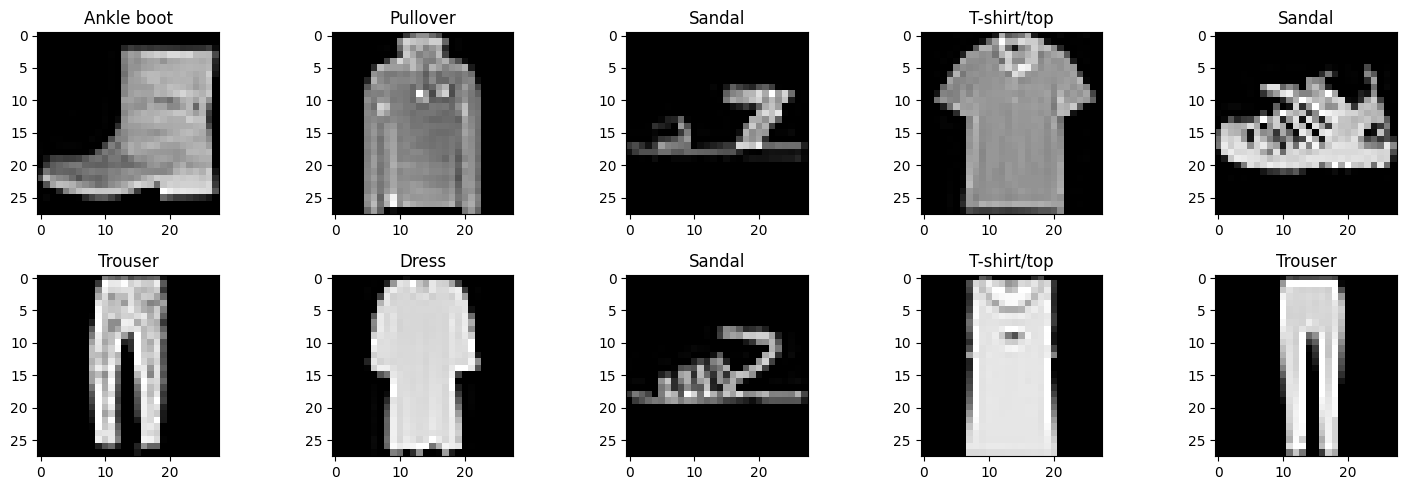

In [83]:
import matplotlib.pyplot as plt
fig, axes=plt.subplots(2,5, figsize=(15,5))

for i, ax in enumerate(axes.flat):
  X,y=train_data[i]
  ax.imshow(X.squeeze(), cmap='gray')
  ax.set_title(train_and_valid_data.classes[y])
plt.tight_layout()
plt.show()

In [84]:
X_sample, y_sample=train_data[0]
X_sample

Image([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.2353, 0.2000, 0.2235, 0.1961,
         0.2157, 0.2078, 0.1961, 0.1922, 0.1647, 0.1725, 0.1804, 0.1843, 0.2353,
         0.0431],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0078, 0.0000, 0.5216, 0.6196, 0.5922, 0.7529, 0.7725,
         0.8118, 0.7882, 0.8549, 0.8549, 0.8235, 0.8392

In [85]:
X_sample.shape

torch.Size([1, 28, 28])

In [86]:
X_sample.dtype

torch.float32

In [87]:
X_sample[0]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.2353, 0.2000, 0.2235, 0.1961,
         0.2157, 0.2078, 0.1961, 0.1922, 0.1647, 0.1725, 0.1804, 0.1843, 0.2353,
         0.0431],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0078, 0.0000, 0.5216, 0.6196, 0.5922, 0.7529, 0.7725,
         0.8118, 0.7882, 0.8549, 0.8549, 0.8235, 0.8392

In [88]:
y_sample

9

In [89]:
train_and_valid_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [90]:
class ImageClassifier(nn.Module):
  def __init__(self, n_inputs,n_hidden1, n_hidden2, n_classes):
    super().__init__()
    self.mlp=nn.Sequential(
        nn.Flatten(),
        nn.Linear(n_inputs, n_hidden1),
        nn.ReLU(),
        nn.ReLU(),
        nn.Linear(n_hidden1, n_classes)
    )

  def forward(self, X):
    return self.mlp(X)

torch.manual_seed(42)
model=ImageClassifier(
    n_inputs=28*28,
    n_hidden1=300,
    n_hidden2=100,
    n_classes=10
)


In [91]:
model=model.to(device)

In [92]:
criterion=nn.CrossEntropyLoss()

In [93]:
optimizer=torch.optim.SGD(model.parameters(), lr=0.01)

In [94]:
!pip install torchmetrics

In [95]:
import torchmetrics

In [96]:
accuracy=torchmetrics.Accuracy(
    task='multiclass',
    num_classes=10
).to(device)

In [97]:
epochs=10
for epoch in range(epochs):
  model.train()
  train_loss=0.
  for X_batch, y_batch in train_loader:
    X_batch=X_batch.to(device)
    y_batch=y_batch.to(device)

    y_pred=model(X_batch)
    loss=criterion(y_pred, y_batch)
    train_loss+=loss.item()

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  mean_loss=train_loss / len(train_loader)


  model.eval()
  accuracy.reset()

  with torch.no_grad():
    for X_batch, y_batch in valid_loader:
      X_batch, y_batch=X_batch.to(device), y_batch.to(device)

      y_pred=model(X_batch)
      accuracy.update(y_pred,y_batch)
  val_acc=accuracy.compute().item()
  print(f"Epoch {epoch+1}: train_loss={mean_loss:.4f}, val_acc={val_acc:.4f}")



Epoch 1: train_loss=0.9152, val_acc=0.7814
Epoch 2: train_loss=0.5588, val_acc=0.8092
Epoch 3: train_loss=0.4969, val_acc=0.8316
Epoch 4: train_loss=0.4666, val_acc=0.8372
Epoch 5: train_loss=0.4465, val_acc=0.8416
Epoch 6: train_loss=0.4313, val_acc=0.8414
Epoch 7: train_loss=0.4186, val_acc=0.8470
Epoch 8: train_loss=0.4081, val_acc=0.8526
Epoch 9: train_loss=0.3981, val_acc=0.8526
Epoch 10: train_loss=0.3902, val_acc=0.8482


In [98]:
model.eval()

X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
y_new = y_new[:3].to(device)

with torch.no_grad():
    logits = model(X_new)
    preds = logits.argmax(dim=1)


In [99]:
preds

tensor([7, 4, 2], device='cuda:0')

In [100]:
y_new

tensor([7, 4, 2], device='cuda:0')

In [101]:
logits

tensor([[ -2.4306,  -2.7179,  -2.4196,  -2.6387,  -3.6446,   4.0928,  -2.1560,
           6.6443,   1.2166,   4.0472],
        [  0.0293,   0.8395,   8.8976,   0.8845,  13.2138,  -6.7538,   5.8570,
         -12.5709,   3.3260, -12.5095],
        [  2.2400,  -1.2171,   8.7394,   2.7367,   6.6386,  -5.4299,   5.5577,
         -12.1923,   4.0780,  -9.9863]], device='cuda:0')

In [102]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [103]:
F.softmax(logits, dim=1)

tensor([[9.8928e-05, 7.4226e-05, 1.0002e-04, 8.0338e-05, 2.9382e-05, 6.7360e-02,
         1.3019e-04, 8.6398e-01, 3.7955e-03, 6.4353e-02],
        [1.8535e-06, 4.1671e-06, 1.3166e-02, 4.3590e-06, 9.8614e-01, 2.0995e-09,
         6.2938e-04, 6.2483e-12, 5.0084e-05, 6.6441e-12],
        [1.2777e-03, 4.0277e-05, 8.4936e-01, 2.0998e-03, 1.0393e-01, 5.9627e-07,
         3.5264e-02, 6.8954e-10, 8.0291e-03, 6.2610e-09]], device='cuda:0')

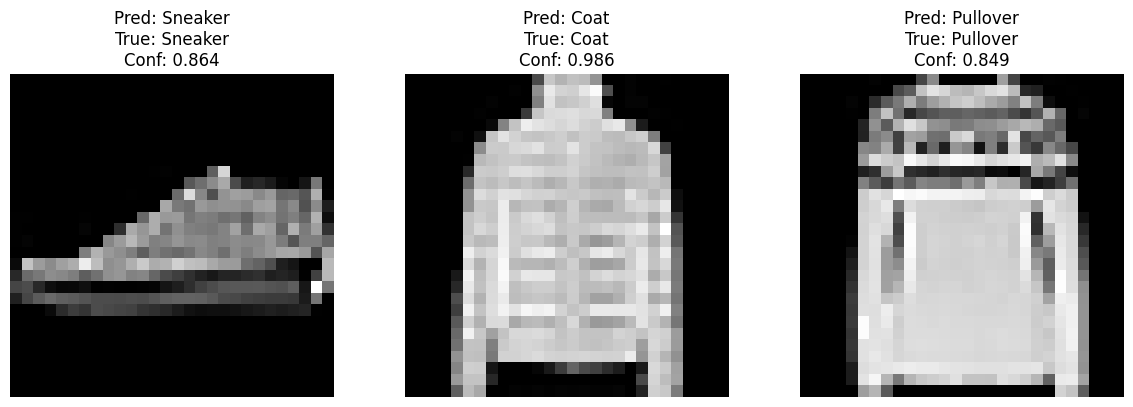

In [104]:
model.eval()

X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
y_new = y_new[:3].to(device)

with torch.no_grad():
    logits = model(X_new)
    probas = F.softmax(logits, dim=1)
    preds = probas.argmax(dim=1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, ax in enumerate(axes):
    image = X_new[i].cpu().squeeze()
    pred_class = train_and_valid_data.classes[preds[i].cpu()]
    true_class = train_and_valid_data.classes[y_new[i].cpu()]
    confidence = probas[i, preds[i]].item()

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Pred: {pred_class}\nTrue: {true_class}\nConf: {confidence:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [105]:
y_top4_logits, y_top4_indices = torch.topk(logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_logits, dim=1)
y_top4_probas.round(decimals=3)

tensor([[0.8640, 0.0670, 0.0640, 0.0040],
        [0.9860, 0.0130, 0.0010, 0.0000],
        [0.8520, 0.1040, 0.0350, 0.0080]], device='cuda:0')

#Fine-Tuning Neural Network Hyperparameters with Optuna

In [106]:
%pip install optuna

In [107]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna

In [108]:
def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)

    model = ImageClassifier(
        n_inputs=1 * 28 * 28,
        n_hidden1=n_hidden,
        n_hidden2=n_hidden,
        n_classes=10).to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion =nn.CrossEntropyLoss()

    n_epochs=10
    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
    model.eval()
    accuracy.reset()
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            preds = logits.argmax(dim=1)
            accuracy.update(preds, y_batch)
        validation_accuracy=accuracy.compute().item()    #accuracy.compute() çox vaxt tensor qaytarır. Optuna isə adətən plain Python number ilə daha rahat işləyi
    return validation_accuracy

In [109]:
torch.manual_seed(42)

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)

study.optimize(objective, n_trials=3)

print("Best params:", study.best_params)
print("Best validation accuracy:", study.best_value)

[I 2026-04-03 12:28:52,378] A new study created in memory with name: no-name-828872ed-d5e5-4e23-a1b6-6cd06943f4b6
[I 2026-04-03 12:31:30,644] Trial 0 finished with value: 0.6980000138282776 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.6980000138282776.
[I 2026-04-03 12:34:00,743] Trial 1 finished with value: 0.8496000170707703 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.8496000170707703.
[I 2026-04-03 12:36:32,921] Trial 2 finished with value: 0.4334000051021576 and parameters: {'learning_rate': 4.207988669606632e-05, 'n_hidden': 63}. Best is trial 1 with value: 0.8496000170707703.


Best params: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}
Best validation accuracy: 0.8496000170707703


In [110]:
def objective(trial, train_loader, valid_loader):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)

    model = ImageClassifier(
        n_inputs=1 * 28 * 28,
        n_hidden1=n_hidden,
        n_hidden2=n_hidden,
        n_classes=10).to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion =nn.CrossEntropyLoss()

    n_epochs=10
    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
    model.eval()
    accuracy.reset()
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            preds = logits.argmax(dim=1)
            accuracy.update(preds, y_batch)
        validation_accuracy=accuracy.compute().item()    #accuracy.compute() çox vaxt tensor qaytarır. Optuna isə adətən plain Python number ilə daha rahat işləyi
    return validation_accuracy

objective_with_data= lambda trial : objective(
    trial,
    train_loader=train_loader,
    valid_loader=valid_loader
)

study.optimize(objective_with_data, n_trials=3)

[I 2026-04-03 12:39:12,065] Trial 3 finished with value: 0.2955999970436096 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.8496000170707703.
[I 2026-04-03 12:41:41,931] Trial 4 finished with value: 0.8258000016212463 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.8496000170707703.
[I 2026-04-03 12:44:15,694] Trial 5 finished with value: 0.31679999828338623 and parameters: {'learning_rate': 1.2087541473056957e-05, 'n_hidden': 292}. Best is trial 1 with value: 0.8496000170707703.


In [111]:
from functools import partial

objective_with_data = partial(
    objective,
    train_loader=train_loader,
    valid_loader=valid_loader
)

study.optimize(objective_with_data, n_trials=3)

[I 2026-04-03 12:46:45,464] Trial 6 finished with value: 0.8636000156402588 and parameters: {'learning_rate': 0.021368329072358756, 'n_hidden': 79}. Best is trial 6 with value: 0.8636000156402588.
[I 2026-04-03 12:49:15,181] Trial 7 finished with value: 0.45879998803138733 and parameters: {'learning_rate': 5.3370327626039544e-05, 'n_hidden': 71}. Best is trial 6 with value: 0.8636000156402588.
[I 2026-04-03 12:51:45,798] Trial 8 finished with value: 0.6570000052452087 and parameters: {'learning_rate': 0.00016480446427978953, 'n_hidden': 167}. Best is trial 6 with value: 0.8636000156402588.


In [112]:
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=0,
    interval_steps=1
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner
)

[I 2026-04-03 12:51:45,808] A new study created in memory with name: no-name-1f1f3c05-decc-42dd-a39c-d46855128ff3


In [113]:
import optuna

def objective(trial, train_loader, valid_loader):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)

    model = ImageClassifier(
        n_inputs=28 * 28,
        n_hidden1=n_hidden,
        n_hidden2=n_hidden,
        n_classes=10
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    n_epochs = 5

    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch)
                preds = logits.argmax(dim=1)

                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        validation_accuracy = correct / total

        trial.report(validation_accuracy, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return validation_accuracy




#Saving and Loading PyTorch Models

In [114]:
model

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): ReLU()
    (4): Linear(in_features=300, out_features=10, bias=True)
  )
)

In [115]:
model.state_dict()

OrderedDict([('mlp.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0081,  ..., -0.0096,  0.0112,  0.0140],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0082,  0.0008,  0.0117],
                      [-0.0008,  0.0017,  0.0048,  ..., -0.0105, -0.0180,  0.0060],
                      ...,
                      [-0.0283,  0.0160, -0.0331,  ..., -0.0237, -0.0290,  0.0024],
                      [ 0.0149, -0.0222,  0.0158,  ...,  0.0002,  0.0009,  0.0010],
                      [ 0.0060, -0.0063, -0.0115,  ...,  0.0209,  0.0137, -0.0051]],
                     device='cuda:0')),
             ('mlp.1.bias',
              tensor([ 5.5528e-02,  6.9970e-02,  4.5793e-02, -7.5618e-02,  2.3903e-02,
                       3.2231e-02, -6.5251e-02,  1.6770e-02,  1.2163e-02,  2.7244e-02,
                       1.1196e-02,  1.8690e-01,  1.5307e-02, -4.0821e-02, -9.8203e-03,
                      -3.8530e-02,  1.4085e-01, -1.6377e-01, -2.2244e-02,  7.6353e-02,
                      

In [116]:
torch.save(model, "my_fashion_mnist.pt")

In [117]:
loaded_model = torch.load("my_fashion_mnist.pt", weights_only=False)

In [118]:
loaded_model

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): ReLU()
    (4): Linear(in_features=300, out_features=10, bias=True)
  )
)

In [119]:
X_new

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]], device='cuda:0')

In [120]:
y_new

tensor([7, 4, 2], device='cuda:0')

In [121]:
loaded_model.eval()
y_pred_logits = loaded_model(X_new)

In [122]:
y_pred_logits

tensor([[ -2.4306,  -2.7179,  -2.4196,  -2.6387,  -3.6446,   4.0928,  -2.1560,
           6.6443,   1.2166,   4.0472],
        [  0.0293,   0.8395,   8.8976,   0.8845,  13.2138,  -6.7538,   5.8570,
         -12.5709,   3.3260, -12.5095],
        [  2.2400,  -1.2171,   8.7394,   2.7367,   6.6386,  -5.4299,   5.5577,
         -12.1923,   4.0780,  -9.9863]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [123]:
new_model = ImageClassifier(
    n_inputs=1 * 28 * 28,
    n_hidden1=300,
    n_hidden2=100,
    n_classes=10
    )

torch.save(model.state_dict(), "my_fashion_mnist_weights.pt")


In [124]:
loaded_weights = torch.load("my_fashion_mnist_weights.pt", weights_only=True)
new_model.load_state_dict(loaded_weights)
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): ReLU()
    (4): Linear(in_features=300, out_features=10, bias=True)
  )
)

In [125]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {
        "n_inputs": 1 * 28 * 28,
        "n_hidden1": 300,
        "n_hidden2": 100,
        "n_classes": 10
    }
}

torch.save(model_data, "my_fashion_mnist_model.pt")

In [126]:
loaded_data = torch.load("my_fashion_mnist_model.pt", weights_only=True)
new_model = ImageClassifier(**loaded_data["model_hyperparameters"])
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): ReLU()
    (4): Linear(in_features=300, out_features=10, bias=True)
  )
)

In [127]:
loaded_data

{'model_state_dict': OrderedDict([('mlp.1.weight',
               tensor([[ 0.0273,  0.0296, -0.0081,  ..., -0.0096,  0.0112,  0.0140],
                       [-0.0188, -0.0354,  0.0187,  ..., -0.0082,  0.0008,  0.0117],
                       [-0.0008,  0.0017,  0.0048,  ..., -0.0105, -0.0180,  0.0060],
                       ...,
                       [-0.0283,  0.0160, -0.0331,  ..., -0.0237, -0.0290,  0.0024],
                       [ 0.0149, -0.0222,  0.0158,  ...,  0.0002,  0.0009,  0.0010],
                       [ 0.0060, -0.0063, -0.0115,  ...,  0.0209,  0.0137, -0.0051]],
                      device='cuda:0')),
              ('mlp.1.bias',
               tensor([ 5.5528e-02,  6.9970e-02,  4.5793e-02, -7.5618e-02,  2.3903e-02,
                        3.2231e-02, -6.5251e-02,  1.6770e-02,  1.2163e-02,  2.7244e-02,
                        1.1196e-02,  1.8690e-01,  1.5307e-02, -4.0821e-02, -9.8203e-03,
                       -3.8530e-02,  1.4085e-01, -1.6377e-01, -2.2244e-02,  

In [128]:
checkpoint = {
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()

}

torch.save(checkpoint, "checkpoint.pth")

In [129]:
new_model = ImageClassifier(
    n_inputs=1 * 28 * 28,
    n_hidden1=300,
    n_hidden2=100,
    n_classes=10
).to(device)

In [130]:
new_model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [131]:
new_optimizer = torch.optim.SGD(new_model.parameters(), lr=0.01)

In [132]:
new_optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

In [133]:
start_epoch = checkpoint["epoch"]
print(start_epoch)

9


In [134]:
new_model.train()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): ReLU()
    (4): Linear(in_features=300, out_features=10, bias=True)
  )
)

In [135]:
for epoch in range(start_epoch + 1, 13):
    new_model.train()
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        new_optimizer.zero_grad()
        logits = new_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        new_optimizer.step()

#Compiling and Optimizing a PyTorch Model

In [136]:
torchscript_model = torch.jit.trace(model, X_new)

In [137]:
torchscript_model

ImageClassifier(
  original_name=ImageClassifier
  (mlp): Sequential(
    original_name=Sequential
    (0): Flatten(original_name=Flatten)
    (1): Linear(original_name=Linear)
    (2): ReLU(original_name=ReLU)
    (3): ReLU(original_name=ReLU)
    (4): Linear(original_name=Linear)
  )
)

In [138]:
torchscript_model = torch.jit.script(model)

In [139]:
torchscript_model

RecursiveScriptModule(
  original_name=ImageClassifier
  (mlp): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Flatten)
    (1): RecursiveScriptModule(original_name=Linear)
    (2): RecursiveScriptModule(original_name=ReLU)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Linear)
  )
)

In [140]:
optimized_model = torch.jit.optimize_for_inference(torchscript_model)

In [141]:
optimized_model

RecursiveScriptModule(original_name=ImageClassifier)

In [142]:
torchscript_model.save('my_fashion_mnist_torchscript.pt')

In [143]:
loaded_torchscript_model = torch.jit.load("my_fashion_mnist_torchscript.pt")

In [144]:
loaded_torchscript_model

RecursiveScriptModule(
  original_name=ImageClassifier
  (mlp): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Flatten)
    (1): RecursiveScriptModule(original_name=Linear)
    (2): RecursiveScriptModule(original_name=ReLU)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Linear)
  )
)

In [145]:
compiled_model = torch.compile(model)

In [146]:
compiled_model

OptimizedModule(
  (_orig_mod): ImageClassifier(
    (mlp): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=784, out_features=300, bias=True)
      (2): ReLU()
      (3): ReLU()
      (4): Linear(in_features=300, out_features=10, bias=True)
    )
  )
)